## Down Syndrome Data Exploration

### Common Imports

In [58]:
import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
# suppress warnings
import warnings

warnings.filterwarnings("ignore")

### Load Data

In [60]:
chunks = pkl.load(open("../../../data/interim/down_syndrome/chunks_filtered.pkl", "rb"))
target_chunks = pkl.load(
    open("../../../data/interim/down_syndrome/target_chunks.pkl", "rb")
)
feature_importances = pkl.load(
    open("../../../data/processed/down_syndrome/feature_importances_df.pkl", "rb")
)

In [61]:
df = pd.concat(chunks).reset_index(drop=True)
target = pd.concat(target_chunks).reset_index(drop=True)

df["target"] = target

In [62]:
top_features = feature_importances.loc[feature_importances["importance"] > 0.01]

top_features

,feature,importance
252,Numerical Pipeline__fathers_combined_age,0.059671
265,Numerical Pipeline__mothers_height_in_inches,0.059268
256,Numerical Pipeline__interval_since_last_live_b...,0.055620
260,Numerical Pipeline__weight_gain_recode,0.042957
266,Numerical Pipeline__BMI,0.036885
253,Numerical Pipeline__prior_births_now_living,0.035351
258,Numerical Pipeline__interval_since_last_pregna...,0.033342
259,Numerical Pipeline__pre_pregnancy_weight_recode,0.032373
251,Numerical Pipeline__mothers_single_year_age,0.030958
255,Numerical Pipeline__prior_other_terminations,0.027016


### Cleaning Up Encoded NAs

We'd like to view the raw data with NAs included for now, but some columns we're interested in have encoded missing values in a way that we need to account for manually.

In [ ]:
df["fathers_combined_age"] = df["fathers_combined_age"].replace(99, pd.NA)
df["interval_since_last_live_birth"] = df["interval_since_last_live_birth"].replace(
    [888, 999], pd.NA
)
df["interval_since_last_other_pregnancy_recode"] = df[
    "interval_since_last_other_pregnancy_recode"
].replace([888, 999], pd.NA)
df["interval_since_last_pregnancy_recode"] = df[
    "interval_since_last_pregnancy_recode"
].replace([888, 999], pd.NA)
df["prior_other_terminations"] = df["prior_other_terminations"].replace(99, pd.NA)
df["prior_births_now_living"] = df["prior_births_now_living"].replace(99, pd.NA)
df["pre_pregnancy_weight_recode"] = df["pre_pregnancy_weight_recode"].replace(
    999, pd.NA
)
df["mothers_hispanic_origin_recode"] = df["mothers_hispanic_origin_recode"].replace(
    9, pd.NA
)
df["fathers_hispanic_origin"] = df["fathers_hispanic_origin"].replace(9, pd.NA)

In [83]:
missing_values_df = df.isna().sum().reset_index()

missing_values_df

,index,0
0,mothers_single_year_age,0
1,mothers_age_recode_14,0
2,mothers_age_recode_9,0
3,mothers_nativity,0
4,mothers_residence_status,0
...,...,...
61,limb_reduction_defect,0
62,cleft_lip,0
63,cleft_palate,0
64,hypospadias,0


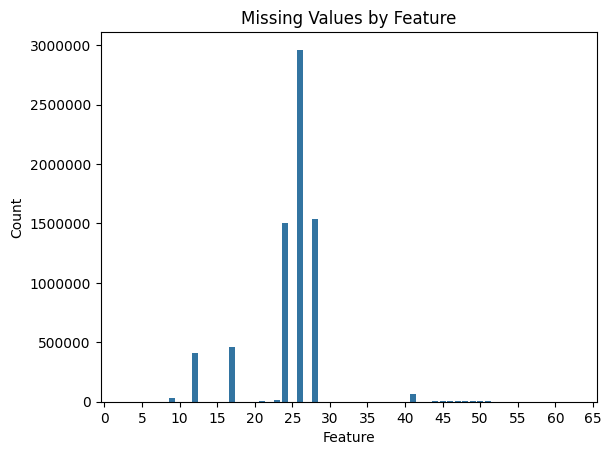

In [86]:
missing_values_ax = sns.barplot(
    data=missing_values_df,
    x=missing_values_df.index,
    y=0,
)
missing_values_ax.set_title("Missing Values by Feature")
missing_values_ax.set_xlabel("Feature")
missing_values_ax.set_ylabel("Count")
missing_values_ax.set_xticks(range(0, len(missing_values_df.index), 5))
missing_values_ax.set_yticks(
    range(0, 3000001, 500000), labels=range(0, 3000001, 500000)
)
plt.show()

We won't use any of the "interval since" features in the final model due to their significant NA ratio. We believe the information gained from those features may instead be inferred from other features, such as the mother's age.

### Univariate Visualizations

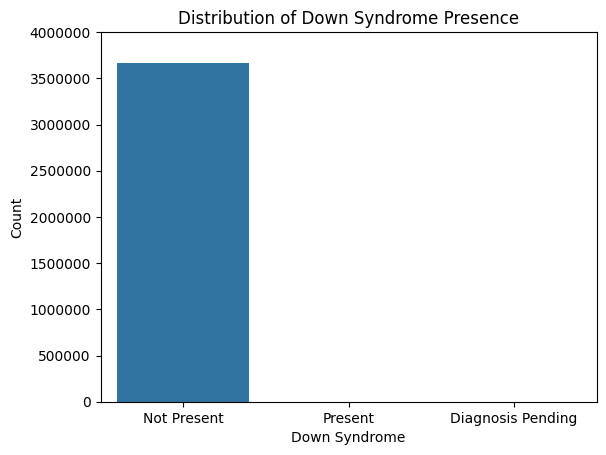

In [88]:
down_syndrome_value_counts = df["target"].value_counts()

down_syndrome_bar_ax = sns.barplot(
    x=down_syndrome_value_counts.index,
    y=down_syndrome_value_counts.values,
)

down_syndrome_bar_ax.set_title("Distribution of Down Syndrome Presence")
down_syndrome_bar_ax.set_xlabel("Down Syndrome")
down_syndrome_bar_ax.set_xticks(
    ticks=[0, 1, 2], labels=["Not Present", "Present", "Diagnosis Pending"]
)
down_syndrome_bar_ax.set_ylabel("Count")
down_syndrome_bar_ax.set_yticks(
    ticks=range(0, 4000001, 500000), labels=range(0, 4000001, 500000)
)
plt.show()

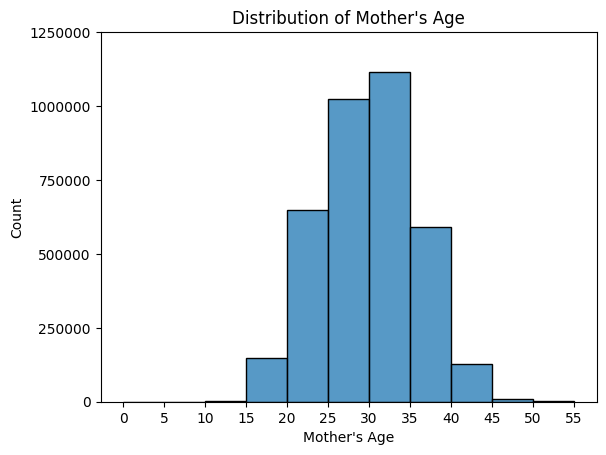

In [91]:
mothers_age_value_counts = df["mothers_single_year_age"].value_counts()

mothers_age_bar_ax = sns.histplot(
    x=mothers_age_value_counts.index,
    weights=mothers_age_value_counts.values,
    bins=range(0, 60, 5),
)
mothers_age_bar_ax.set_title("Distribution of Mother's Age")
mothers_age_bar_ax.set_xlabel("Mother's Age")
mothers_age_bar_ax.set_ylabel("Count")
mothers_age_bar_ax.set_xticks(range(0, 60, 5))
mothers_age_bar_ax.set_yticks(
    range(0, 1250001, 250000), labels=range(0, 1250001, 250000)
)
plt.show()

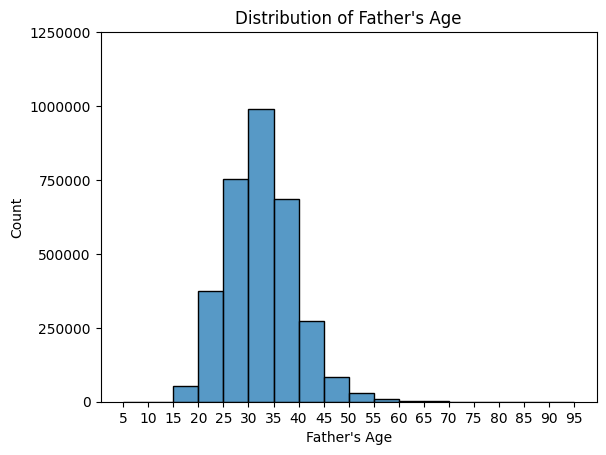

In [93]:
fathers_age_value_counts = df["fathers_combined_age"].value_counts()

fathers_age_bar_ax = sns.histplot(
    x=fathers_age_value_counts.index,
    weights=fathers_age_value_counts.values,
    bins=range(5, 99, 5),
)
fathers_age_bar_ax.set_title("Distribution of Father's Age")
fathers_age_bar_ax.set_xlabel("Father's Age")
fathers_age_bar_ax.set_ylabel("Count")
fathers_age_bar_ax.set_xticks(range(5, 99, 5))
fathers_age_bar_ax.set_yticks(
    range(0, 1250001, 250000), labels=range(0, 1250001, 250000)
)
plt.show()

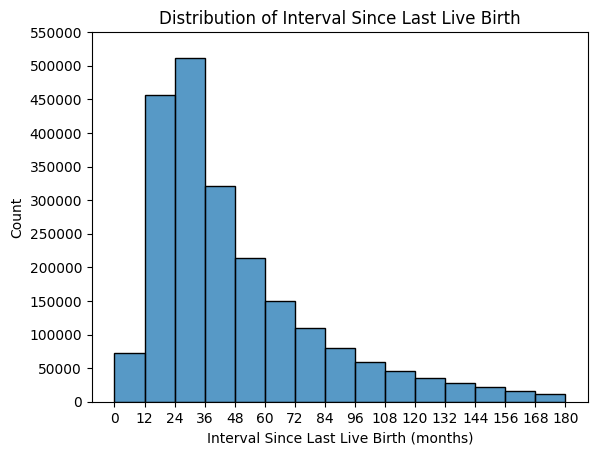

In [96]:
interval_since_last_live_birth_value_counts = df[
    "interval_since_last_live_birth"
].value_counts()

interval_since_last_live_birth_bar_ax = sns.histplot(
    x=interval_since_last_live_birth_value_counts.index,
    weights=interval_since_last_live_birth_value_counts.values,
    bins=range(0, 181, 12),
)
interval_since_last_live_birth_bar_ax.set_title(
    "Distribution of Interval Since Last Live Birth"
)
interval_since_last_live_birth_bar_ax.set_xlabel(
    "Interval Since Last Live Birth (months)"
)
interval_since_last_live_birth_bar_ax.set_ylabel("Count")
interval_since_last_live_birth_bar_ax.set_xticks(range(0, 181, 12))
interval_since_last_live_birth_bar_ax.set_yticks(
    range(0, 550001, 50000), labels=range(0, 550001, 50000)
)
plt.show()

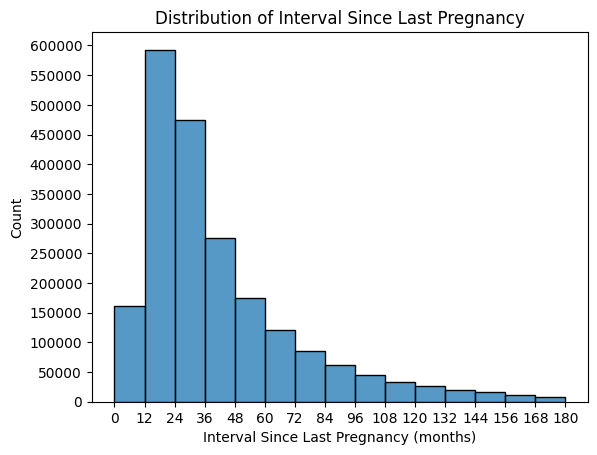

In [98]:
interval_since_last_pregnancy_recode_value_counts = df[
    "interval_since_last_pregnancy_recode"
].value_counts()

interval_since_last_pregnancy_recode_bar_ax = sns.histplot(
    x=interval_since_last_pregnancy_recode_value_counts.index,
    weights=interval_since_last_pregnancy_recode_value_counts.values,
    bins=range(0, 181, 12),
)
interval_since_last_pregnancy_recode_bar_ax.set_title(
    "Distribution of Interval Since Last Pregnancy"
)
interval_since_last_pregnancy_recode_bar_ax.set_xlabel(
    "Interval Since Last Pregnancy (months)"
)
interval_since_last_pregnancy_recode_bar_ax.set_ylabel("Count")
interval_since_last_pregnancy_recode_bar_ax.set_xticks(range(0, 181, 12))
interval_since_last_pregnancy_recode_bar_ax.set_yticks(
    range(0, 600001, 50000), labels=range(0, 600001, 50000)
)
plt.show()

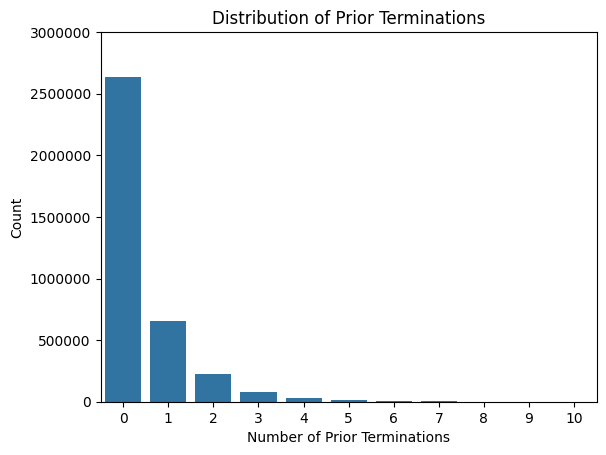

In [99]:
prior_terminations_value_counts = df["prior_other_terminations"].value_counts()

prior_terminations_bar_ax = sns.barplot(
    x=prior_terminations_value_counts.index,
    y=prior_terminations_value_counts.values,
)
prior_terminations_bar_ax.set_title("Distribution of Prior Terminations")
prior_terminations_bar_ax.set_xlabel("Number of Prior Terminations")
prior_terminations_bar_ax.set_ylabel("Count")
prior_terminations_bar_ax.set_xlim(-0.5, 10.5)
prior_terminations_bar_ax.set_xticks(range(0, 11))
prior_terminations_bar_ax.set_yticks(
    range(0, 3000001, 500000), labels=range(0, 3000001, 500000)
)
plt.show()

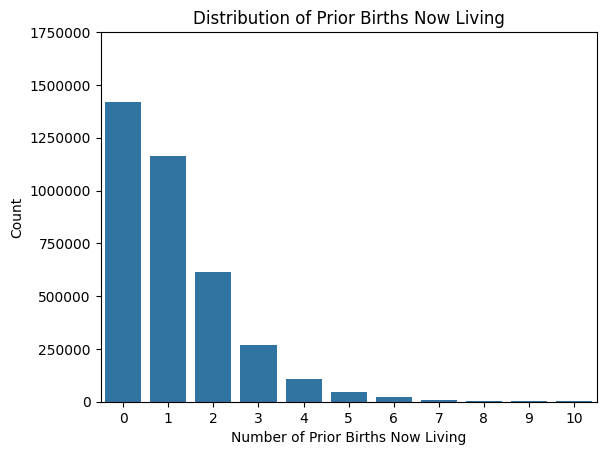

In [74]:
prior_births_now_living_value_counts = df["prior_births_now_living"].value_counts()

prior_births_now_living_bar_ax = sns.barplot(
    x=prior_births_now_living_value_counts.index,
    y=prior_births_now_living_value_counts.values,
)
prior_births_now_living_bar_ax.set_title("Distribution of Prior Births Now Living")
prior_births_now_living_bar_ax.set_xlabel("Number of Prior Births Now Living")
prior_births_now_living_bar_ax.set_ylabel("Count")
prior_births_now_living_bar_ax.set_xlim(-0.5, 10.5)
prior_births_now_living_bar_ax.set_xticks(range(0, 11))
prior_births_now_living_bar_ax.set_yticks(
    range(0, 1750001, 250000), labels=range(0, 1750001, 250000)
)
plt.show()

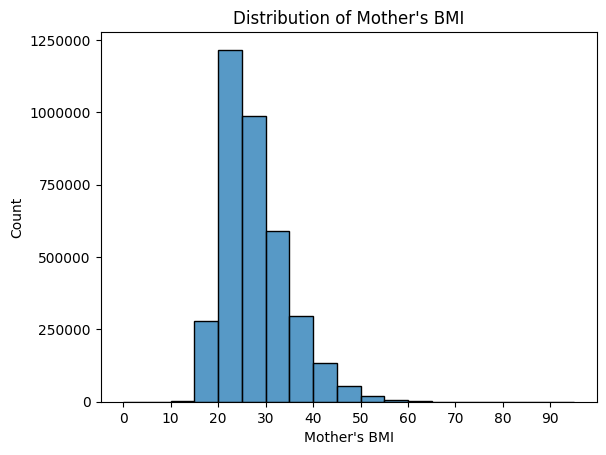

In [75]:
BMI_value_counts = df["BMI"].value_counts()

BMI_bar_ax = sns.histplot(
    x=BMI_value_counts.index, weights=BMI_value_counts.values, bins=range(0, 100, 5)
)
BMI_bar_ax.set_title("Distribution of Mother's BMI")
BMI_bar_ax.set_xlabel("Mother's BMI")
BMI_bar_ax.set_xticks(ticks=range(0, 100, 10))
BMI_bar_ax.set_yticks(range(0, 1250001, 250000), labels=range(0, 1250001, 250000))
BMI_bar_ax.set_ylabel("Count")
plt.show()

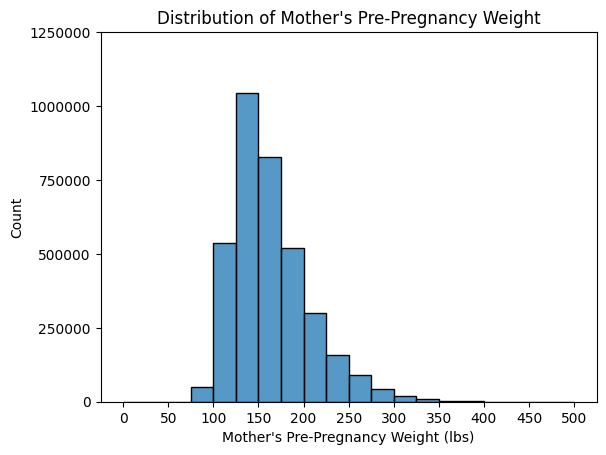

In [76]:
pre_pregnancy_weight_value_counts = df["pre_pregnancy_weight_recode"].value_counts()

pre_pregnancy_weight_bar_ax = sns.histplot(
    x=pre_pregnancy_weight_value_counts.index,
    weights=pre_pregnancy_weight_value_counts.values,
    bins=range(0, 501, 25),
)
pre_pregnancy_weight_bar_ax.set_title("Distribution of Mother's Pre-Pregnancy Weight")
pre_pregnancy_weight_bar_ax.set_xlabel("Mother's Pre-Pregnancy Weight (lbs)")
pre_pregnancy_weight_bar_ax.set_xticks(range(0, 501, 50))
pre_pregnancy_weight_bar_ax.set_yticks(
    range(0, 1250001, 250000), labels=range(0, 1250001, 250000)
)
pre_pregnancy_weight_bar_ax.set_ylabel("Count")
plt.show()

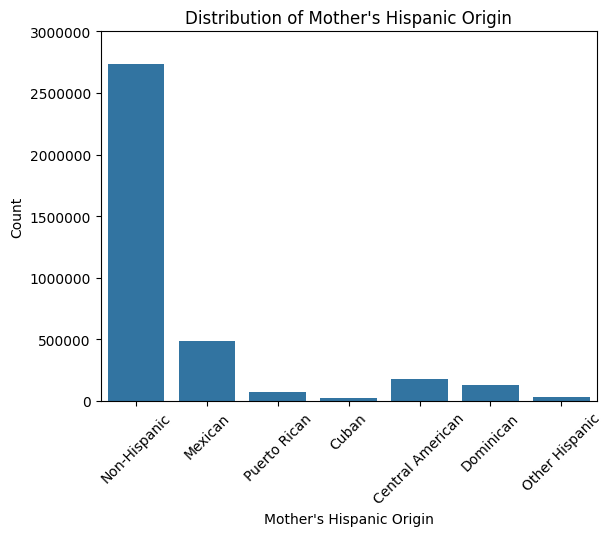

In [77]:
mothers_hispanic_origin_value_counts = df[
    "mothers_hispanic_origin_recode"
].value_counts()

mothers_hispanic_origin_bar_ax = sns.barplot(
    x=mothers_hispanic_origin_value_counts.index,
    y=mothers_hispanic_origin_value_counts.values,
)
mothers_hispanic_origin_bar_ax.set_title("Distribution of Mother's Hispanic Origin")
mothers_hispanic_origin_bar_ax.set_xlabel("Mother's Hispanic Origin")
mothers_hispanic_origin_bar_ax.set_ylabel("Count")
mothers_hispanic_origin_bar_ax.set_xticklabels(
    [
        "Non-Hispanic",
        "Mexican",
        "Puerto Rican",
        "Cuban",
        "Central American",
        "Dominican",
        "Other Hispanic",
    ],
    rotation=45,
)
mothers_hispanic_origin_bar_ax.set_yticks(
    range(0, 3000001, 500000), labels=range(0, 3000001, 500000)
)

plt.show()

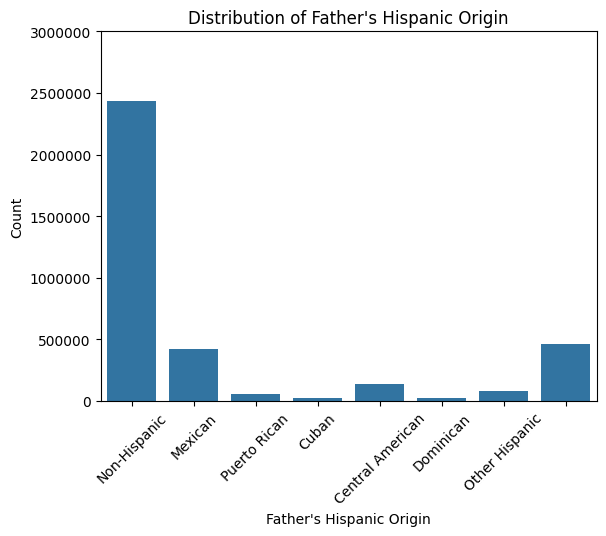

In [78]:
fathers_hispanic_origin_value_counts = df["fathers_hispanic_origin"].value_counts()

fathers_hispanic_origin_bar_ax = sns.barplot(
    x=fathers_hispanic_origin_value_counts.index,
    y=fathers_hispanic_origin_value_counts.values,
)
fathers_hispanic_origin_bar_ax.set_title("Distribution of Father's Hispanic Origin")
fathers_hispanic_origin_bar_ax.set_xlabel("Father's Hispanic Origin")
fathers_hispanic_origin_bar_ax.set_ylabel("Count")
fathers_hispanic_origin_bar_ax.set_xticklabels(
    [
        "Non-Hispanic",
        "Mexican",
        "Puerto Rican",
        "Cuban",
        "Central American",
        "Dominican",
        "Other Hispanic",
    ],
    rotation=45,
)
fathers_hispanic_origin_bar_ax.set_yticks(
    range(0, 3000001, 500000), labels=range(0, 3000001, 500000)
)

plt.show()

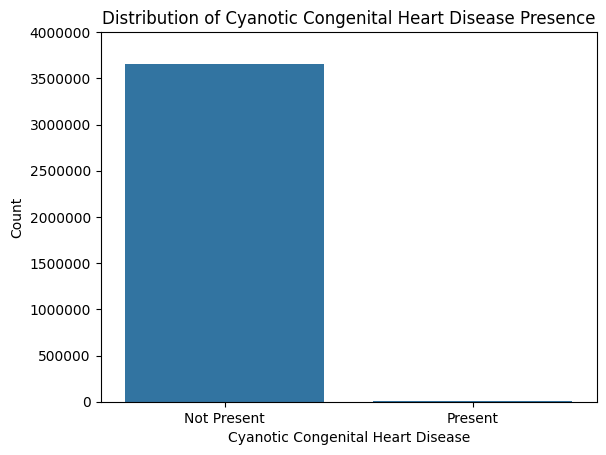

In [79]:
cyanotic_congenital_heart_disease_value_counts = df[
    "cyanotic_congenital_heart_disease"
].value_counts()

cyanotic_congenital_heart_disease_bar_ax = sns.barplot(
    x=cyanotic_congenital_heart_disease_value_counts.index,
    y=cyanotic_congenital_heart_disease_value_counts.values,
)
cyanotic_congenital_heart_disease_bar_ax.set_title(
    "Distribution of Cyanotic Congenital Heart Disease Presence"
)
cyanotic_congenital_heart_disease_bar_ax.set_xlabel("Cyanotic Congenital Heart Disease")
cyanotic_congenital_heart_disease_bar_ax.set_ylabel("Count")
cyanotic_congenital_heart_disease_bar_ax.set_xticklabels(["Not Present", "Present"])
cyanotic_congenital_heart_disease_bar_ax.set_yticks(
    range(0, 4000001, 500000), labels=range(0, 4000001, 500000)
)
plt.show()

### Bivariate Visualizations

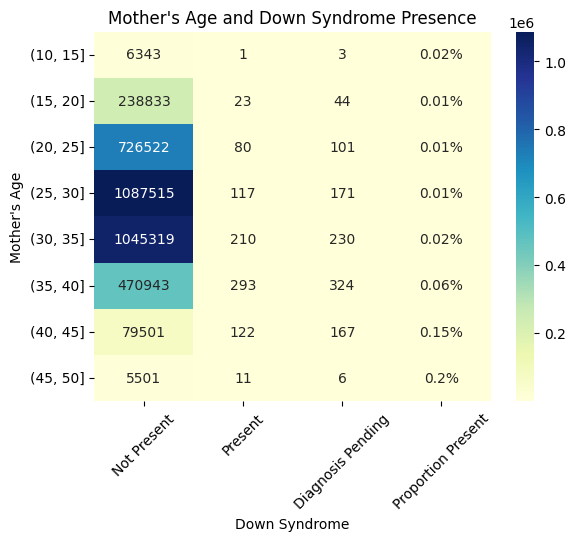

In [105]:
mothers_age_cross_tab = pd.crosstab(
    pd.cut(df["mothers_single_year_age"], bins=range(0, 61, 5)), df["target"]
)
mothers_age_cross_tab["proportion"] = (
    round(
        mothers_age_cross_tab[1].astype(float)
        / (
            mothers_age_cross_tab[0].astype(float)
            + mothers_age_cross_tab[1].astype(float)
            + mothers_age_cross_tab[2].astype(float)
        ),
        4,
    )
    * 100
)

annotation_matrix = mothers_age_cross_tab.copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion"] = round(mothers_age_cross_tab["proportion"], 2)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

mothers_age_cross_tab_ax = sns.heatmap(
    mothers_age_cross_tab, cmap="YlGnBu", annot=annotation_matrix.values, fmt=""
)
mothers_age_cross_tab_ax.set_title("Mother's Age and Down Syndrome Presence")
mothers_age_cross_tab_ax.set_xlabel("Down Syndrome")
mothers_age_cross_tab_ax.set_xticklabels(
    ["Not Present", "Present", "Diagnosis Pending", "Proportion Present"], rotation=45
)
mothers_age_cross_tab_ax.set_ylabel("Mother's Age")
plt.show()

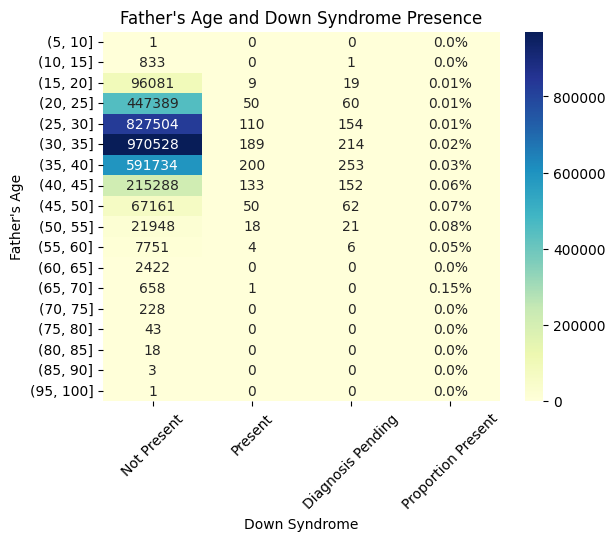

In [106]:
fathers_age_cross_tab = pd.crosstab(
    pd.cut(
        df["fathers_combined_age"].dropna(),
        bins=range(0, 101, 5),
    ),
    target,
)
fathers_age_cross_tab["proportion"] = (
    round(
        fathers_age_cross_tab[1].astype(float)
        / (
            fathers_age_cross_tab[0]
            + fathers_age_cross_tab[1]
            + fathers_age_cross_tab[2]
        ),
        4,
    )
    * 100
)

annotation_matrix = fathers_age_cross_tab.copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion"] = round(fathers_age_cross_tab["proportion"], 2)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

fathers_age_cross_tab_ax = sns.heatmap(
    fathers_age_cross_tab, cmap="YlGnBu", annot=annotation_matrix.values, fmt=""
)
fathers_age_cross_tab_ax.set_title("Father's Age and Down Syndrome Presence")
fathers_age_cross_tab_ax.set_xlabel("Down Syndrome")
fathers_age_cross_tab_ax.set_xticklabels(
    ["Not Present", "Present", "Diagnosis Pending", "Proportion Present"], rotation=45
)
fathers_age_cross_tab_ax.set_ylabel("Father's Age")

plt.show()

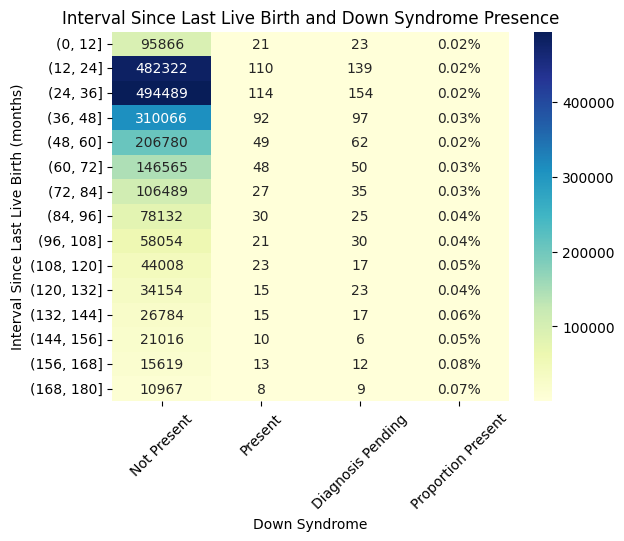

In [107]:
interval_since_last_live_birth_cross_tab = pd.crosstab(
    pd.cut(
        df["interval_since_last_live_birth"].dropna(),
        bins=range(0, 181, 12),
    ),
    df["target"],
)
interval_since_last_live_birth_cross_tab["proportion"] = (
    round(
        interval_since_last_live_birth_cross_tab[1].astype(float)
        / (
            interval_since_last_live_birth_cross_tab[0]
            + interval_since_last_live_birth_cross_tab[1]
            + interval_since_last_live_birth_cross_tab[2]
        ),
        4,
    )
    * 100
)

annotation_matrix = interval_since_last_live_birth_cross_tab.copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion"] = round(
    interval_since_last_live_birth_cross_tab["proportion"], 2
)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

interval_since_last_live_birth_cross_tab_ax = sns.heatmap(
    interval_since_last_live_birth_cross_tab,
    cmap="YlGnBu",
    annot=annotation_matrix.values,
    fmt="",
)
interval_since_last_live_birth_cross_tab_ax.set_title(
    "Interval Since Last Live Birth and Down Syndrome Presence"
)
interval_since_last_live_birth_cross_tab_ax.set_xlabel("Down Syndrome")
interval_since_last_live_birth_cross_tab_ax.set_xticklabels(
    ["Not Present", "Present", "Diagnosis Pending", "Proportion Present"], rotation=45
)
interval_since_last_live_birth_cross_tab_ax.set_ylabel(
    "Interval Since Last Live Birth (months)"
)
plt.show()

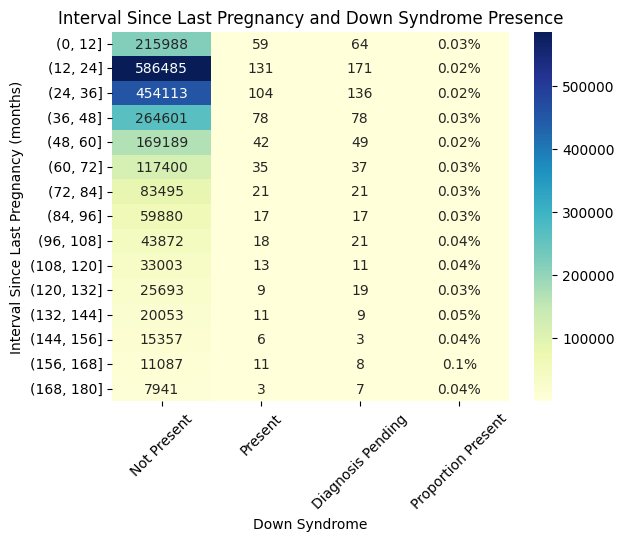

In [108]:
interval_since_last_pregnancy_cross_tab = pd.crosstab(
    pd.cut(
        df["interval_since_last_pregnancy_recode"].dropna(),
        bins=range(0, 181, 12),
    ),
    df["target"],
)
interval_since_last_pregnancy_cross_tab["proportion"] = (
    round(
        interval_since_last_pregnancy_cross_tab[1].astype(float)
        / (
            interval_since_last_pregnancy_cross_tab[0]
            + interval_since_last_pregnancy_cross_tab[1]
            + interval_since_last_pregnancy_cross_tab[2]
        ),
        4,
    )
    * 100
)

annotation_matrix = interval_since_last_pregnancy_cross_tab.copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion"] = round(
    interval_since_last_pregnancy_cross_tab["proportion"], 2
)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

interval_since_last_pregnancy_cross_tab_ax = sns.heatmap(
    interval_since_last_pregnancy_cross_tab,
    cmap="YlGnBu",
    annot=annotation_matrix.values,
    fmt="",
)
interval_since_last_pregnancy_cross_tab_ax.set_title(
    "Interval Since Last Pregnancy and Down Syndrome Presence"
)
interval_since_last_pregnancy_cross_tab_ax.set_xlabel("Down Syndrome")
interval_since_last_pregnancy_cross_tab_ax.set_xticklabels(
    ["Not Present", "Present", "Diagnosis Pending", "Proportion Present"], rotation=45
)
interval_since_last_pregnancy_cross_tab_ax.set_ylabel(
    "Interval Since Last Pregnancy (months)"
)

plt.show()

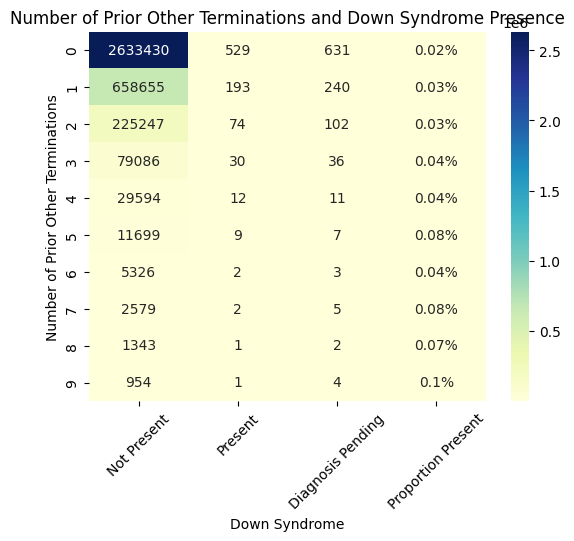

In [136]:
prior_other_terminations_cross_tab = pd.crosstab(
    df["prior_other_terminations"].dropna(), df["target"]
)
prior_other_terminations_cross_tab["proportion"] = (
    round(
        prior_other_terminations_cross_tab[1].astype(float)
        / (
            prior_other_terminations_cross_tab[0]
            + prior_other_terminations_cross_tab[1]
            + prior_other_terminations_cross_tab[2]
        ),
        4,
    )
    * 100
)

annotation_matrix = prior_other_terminations_cross_tab.iloc[0:10, :].copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion"] = round(
    prior_other_terminations_cross_tab["proportion"], 2
)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

prior_other_terminations_cross_tab_ax = sns.heatmap(
    prior_other_terminations_cross_tab.iloc[0:10, :],
    cmap="YlGnBu",
    annot=annotation_matrix.values,
    fmt="",
)
prior_other_terminations_cross_tab_ax.set_title(
    "Number of Prior Other Terminations and Down Syndrome Presence"
)
prior_other_terminations_cross_tab_ax.set_xlabel("Down Syndrome")
prior_other_terminations_cross_tab_ax.set_xticklabels(
    ["Not Present", "Present", "Diagnosis Pending", "Proportion Present"], rotation=45
)
prior_other_terminations_cross_tab_ax.set_ylabel("Number of Prior Other Terminations")

plt.show()

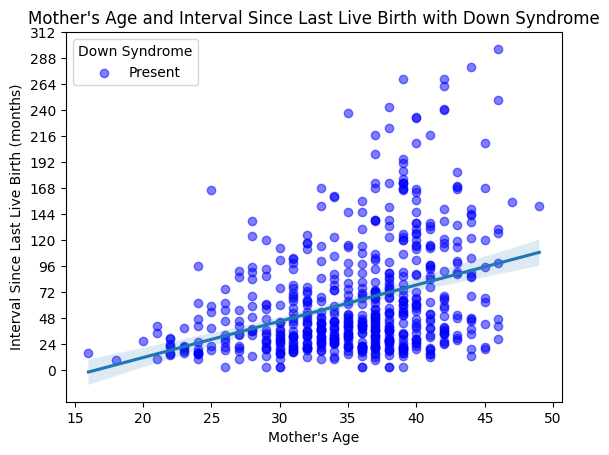

In [129]:
mothers_age_and_interval_since_last_live_birth_ax = sns.regplot(
    data=df[["mothers_single_year_age", "interval_since_last_live_birth", "target"]][
        df["target"] == 1
    ]
    .dropna()
    .astype(int),
    x="mothers_single_year_age",
    y="interval_since_last_live_birth",
    scatter_kws={"alpha": 0.5, "color": "blue"},
)
mothers_age_and_interval_since_last_live_birth_ax.set_title(
    "Mother's Age and Interval Since Last Live Birth with Down Syndrome"
)
mothers_age_and_interval_since_last_live_birth_ax.set_xlabel("Mother's Age")
mothers_age_and_interval_since_last_live_birth_ax.set_ylabel(
    "Interval Since Last Live Birth (months)"
)
mothers_age_and_interval_since_last_live_birth_ax.set_yticks(range(0, 313, 24))
mothers_age_and_interval_since_last_live_birth_ax.set_xticks(range(15, 51, 5))
mothers_age_and_interval_since_last_live_birth_ax.legend(
    title="Down Syndrome", labels=["Present"]
)
plt.show()

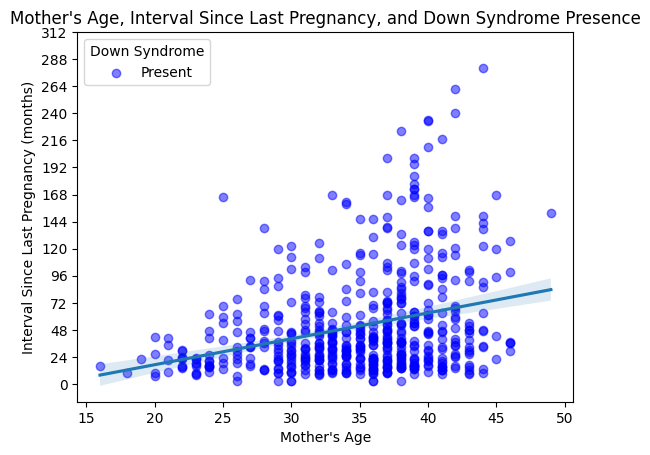

In [ ]:
mothers_age_and_interval_since_pregnancy_ax = sns.regplot(
    data=df[
        ["mothers_single_year_age", "interval_since_last_pregnancy_recode", "target"]
    ][df["target"] == 1]
    .dropna()
    .astype(int),
    x="mothers_single_year_age",
    y="interval_since_last_pregnancy_recode",
    scatter_kws={"alpha": 0.5, "color": "blue"},
)
mothers_age_and_interval_since_pregnancy_ax.set_title(
    "Mother's Age, Interval Since Last Pregnancy, and Down Syndrome Presence"
)
mothers_age_and_interval_since_pregnancy_ax.set_xlabel("Mother's Age")
mothers_age_and_interval_since_pregnancy_ax.set_ylabel(
    "Interval Since Last Pregnancy (months)"
)
mothers_age_and_interval_since_pregnancy_ax.set_yticks(range(0, 313, 24))
mothers_age_and_interval_since_pregnancy_ax.set_xticks(range(15, 51, 5))
mothers_age_and_interval_since_pregnancy_ax.legend(
    title="Down Syndrome", labels=["Present"]
)
plt.show()